In [1]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
elmas_dir = PROJECT_ROOT / "data" / "raw" / "load" / "_elmas_inspect" / "ELMAS_dataset"

clusters = pd.read_csv(
    elmas_dir / "Time_series_18_clusters.csv",
    sep=";",
    decimal=",",
    index_col=0,
)
clusters.index = pd.to_datetime(clusters.index)
clusters.head()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Time,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,121483.881946,15063.691282,48659.199976,38340.208712,36853.123028,22481.656009,25379.868627,46769.754369,19430.080689,230629.450007,64673.316327,23205.994715,32158.570170,56522.475213,27040.916133,81045.181318,27234.438190,15689.622550
2018-01-01 01:00:00,121662.348910,15246.715755,49506.365518,37925.052231,36666.628246,18709.734124,25151.948222,44355.801514,18739.124525,232096.934237,64995.940338,23752.112657,32142.749778,58466.876045,25821.358741,80044.568839,26885.130623,16076.338285
2018-01-01 02:00:00,122048.125157,15372.788346,50884.365716,37752.150669,37042.679019,16965.653600,25109.296178,42534.569188,18341.993755,236371.186342,64254.376173,23940.068391,30837.905646,60183.657941,25284.307515,79790.872405,27091.755817,16036.854800
2018-01-01 03:00:00,122703.504835,15717.004006,51545.616568,37036.920444,37002.148453,16773.511907,25214.020334,42076.425786,18221.133554,239913.156600,64843.825048,23894.241804,30203.841616,63491.323652,25257.515303,78790.098583,27277.920035,16380.716732
2018-01-01 04:00:00,124764.641566,16386.742855,57763.125225,36766.439954,37851.385696,18984.283673,27187.003822,41461.493840,18376.573124,251852.963254,64929.599630,24073.513049,30122.058913,67718.078863,25481.946396,79944.173195,27763.841782,16701.472108


In [2]:
cluster_map = pd.read_csv(
    elmas_dir / "Clusters_after_manual_reclassification.csv",
    sep=";",
)

steel_cluster = cluster_map[
    (cluster_map["Class"] == "24.10") & (cluster_map["Power_level"] == "MV")
]["Cluster"].iloc[0]
steel_cluster

np.int64(1)

5000000.0


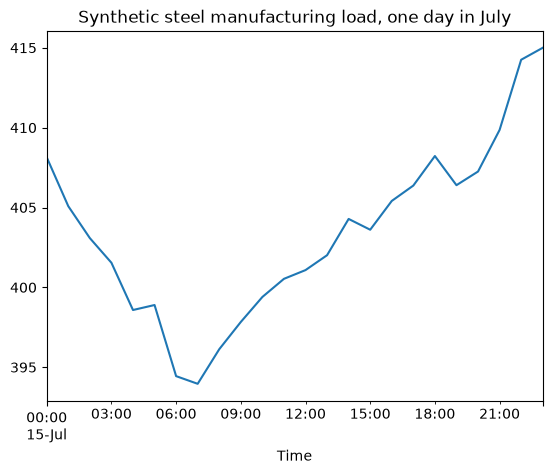

In [3]:
import matplotlib.pyplot as plt

steel_shape = clusters[str(steel_cluster)]
steel_shape = steel_shape / steel_shape.sum()

target_annual_kwh = 5_000_000
steel_profile = steel_shape * target_annual_kwh

print(steel_profile.sum())
steel_profile.loc["2018-07-15"].plot(title="Synthetic steel manufacturing load, one day in July")
plt.show()